# LightGBM Regressor — Dự đoán mức lương

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Thành viên phụ trách:** Chí  
**Thuật toán:** LightGBM Regressor (Light Gradient Boosting Machine)  
**Dataset:** 250K Job Salary Prediction Dataset

---

## Mục tiêu notebook

Notebook này thực hiện toàn bộ quy trình huấn luyện và đánh giá mô hình **LightGBM Regressor** để dự đoán mức lương (`salary`).

Khác với Random Forest (Bagging), LightGBM sử dụng **Gradient Boosting** — các cây được xây dựng tuần tự, mỗi cây học từ phần sai số còn lại của cây trước.

Các bước chính:
1. Load dữ liệu đã tiền xử lý từ Preprocessing notebook  
2. Kiểm tra dữ liệu đầu vào  
3. Huấn luyện mô hình với cross-validation  
4. Đánh giá trên tập test  
5. Phân tích Feature Importance  
6. Xây dựng khoảng dự đoán bằng Quantile Regression  
7. Lưu model và kết quả  


In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\AD\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## 1. Import thư viện

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import joblib
import warnings
import os
import scipy.sparse as sp

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Thư mục lưu ảnh ──────────────────────────────────────────────────────────
FIGURE_DIR = 'figure/LGBM'
os.makedirs(FIGURE_DIR, exist_ok=True)
DATA_DIR   = 'preprocessing_salary_outputs'

print("Thư viện đã sẵn sàng.")
print(f"Figure dir: {FIGURE_DIR}")
print(f"Data dir  : {DATA_DIR}")
print(f"LightGBM version: {lgb.__version__}")


Thư viện đã sẵn sàng.
Figure dir: figure/LGBM
Data dir  : preprocessing_salary_outputs
LightGBM version: 4.6.0


## 2. Load dữ liệu đã tiền xử lý

Dữ liệu được load từ thư mục `preprocessing_salary_outputs/` — cùng nguồn với notebook Random Forest.  

> **Nguyên tắc dùng chung pipeline:**  
> Cả 4 mô hình (LR, RF, XGB, LightGBM) đều sử dụng **cùng một bộ dữ liệu** đã qua chuẩn hóa (StandardScaler) và mã hóa (One-Hot Encoding) từ Preprocessing notebook. Điều này đảm bảo kết quả so sánh giữa các mô hình là **công bằng và nhất quán**.

> **Lưu ý:** LightGBM có thể xử lý trực tiếp sparse matrix — ta giữ nguyên dạng sparse để tiết kiệm bộ nhớ.


In [3]:
# ── Load X (giữ dạng sparse — LightGBM hỗ trợ) ───────────────────────────────
X_train = sp.load_npz(f'{DATA_DIR}/X_train_processed.npz')
X_test  = sp.load_npz(f'{DATA_DIR}/X_test_processed.npz')

# ── Load y ────────────────────────────────────────────────────────────────────
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv')['y_train_model_target']
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv')['y_test_model_target']

# ── Load tên biến ─────────────────────────────────────────────────────────────
feature_names_df = pd.read_csv(f'{DATA_DIR}/04_processed_feature_names.csv')
feature_names = feature_names_df['feature_name'].tolist()

# ── Load preprocessor pipeline ───────────────────────────────────────────────
preprocessor = joblib.load(f'{DATA_DIR}/preprocessor.joblib')

# ── Kiểm tra shape ────────────────────────────────────────────────────────────
print("=" * 55)
print(f"X_train shape  : {X_train.shape}  (sparse: {sp.issparse(X_train)})")
print(f"X_test  shape  : {X_test.shape}")
print(f"y_train shape  : {y_train.shape}")
print(f"y_test  shape  : {y_test.shape}")
print(f"Số features    : {len(feature_names)}")
print("=" * 55)
print(f"y_train — mean: {y_train.mean():,.0f} | median: {y_train.median():,.0f}")
print(f"y_test  — mean: {y_test.mean():,.0f}  | median: {y_test.median():,.0f}")


X_train shape  : (200000, 48)  (sparse: True)
X_test  shape  : (50000, 48)
y_train shape  : (200000,)
y_test  shape  : (50000,)
Số features    : 48
y_train — mean: 145,714 | median: 143,430
y_test  — mean: 145,735  | median: 143,540


## 3. Kiểm tra dữ liệu đầu vào

Missing in X_train : 0
Missing in y_train : 0
Missing in y_test  : 0


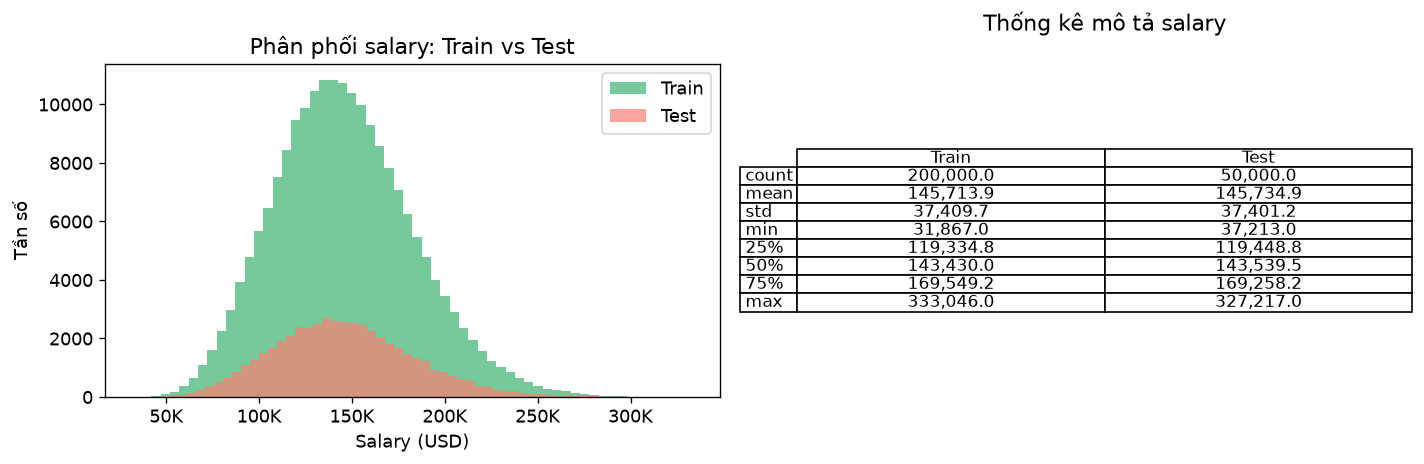

Đã lưu: figure/LGBM/01_salary_distribution.png


In [4]:
# ── Kiểm tra missing ──────────────────────────────────────────────────────────
print(f"Missing in X_train : {(X_train.data == np.nan).sum() if sp.issparse(X_train) else np.isnan(X_train.toarray()).sum()}")
print(f"Missing in y_train : {y_train.isna().sum()}")
print(f"Missing in y_test  : {y_test.isna().sum()}")

# ── Phân phối salary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=60, color='mediumseagreen', alpha=0.7, label='Train')
axes[0].hist(y_test,  bins=60, color='salmon',         alpha=0.7, label='Test')
axes[0].set_title('Phân phối salary: Train vs Test')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Tần số')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend()

stats = pd.DataFrame({'Train': y_train.describe(), 'Test': y_test.describe()})
axes[1].axis('off')
tbl = axes[1].table(
    cellText=[[f'{v:,.1f}' for v in row] for row in stats.values],
    rowLabels=stats.index, colLabels=['Train', 'Test'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
axes[1].set_title('Thống kê mô tả salary', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_salary_distribution.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/LGBM/01_salary_distribution.png")


## 4. Cross-validation với tham số mặc định (Baseline)

Đánh giá mô hình LightGBM với tham số mặc định bằng **5-fold Cross-Validation**
trên tập train.

### Điểm khác biệt quan trọng giữa LightGBM và Random Forest

| Đặc điểm | Random Forest (Bagging) | LightGBM (Boosting) |
|---|---|---|
| Cách xây cây | Song song, độc lập | Tuần tự — cây sau học sai số cây trước |
| Chiến lược phát triển | Level-wise (theo tầng) | **Leaf-wise** (chọn lá có gain lớn nhất) |
| Dự đoán cuối | Trung bình T cây | Tổng M cây có trọng số |
| Tốc độ | Chậm hơn với dữ liệu lớn | **Nhanh hơn** nhờ Histogram-based Learning |
| Overfitting | Ít hơn | Cần kiểm soát qua `num_leaves`, `min_child_samples` |


  LightGBM — Kết quả Cross-Validation (Baseline)
  CV RMSE  :   5,509.03  ± 16.52
  CV R²    :     0.9783  ± 0.0002


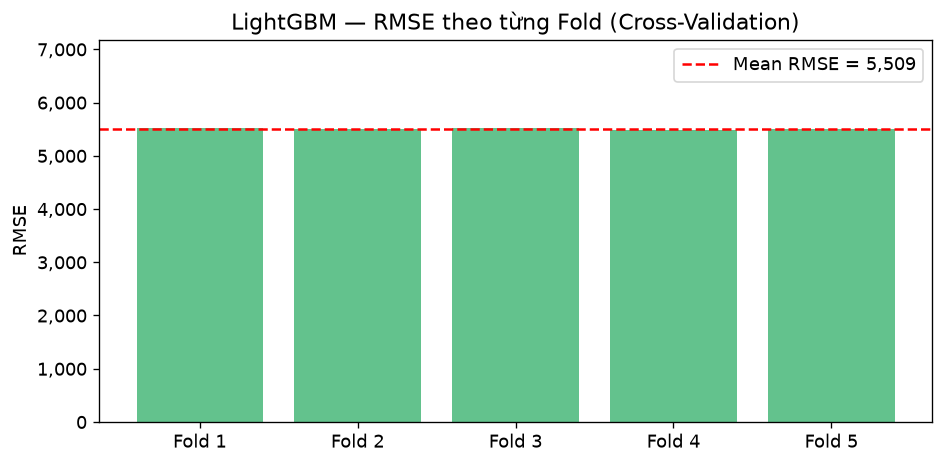

Đã lưu: figure/LGBM/02_cv_rmse_baseline.png


In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lgb_baseline = lgb.LGBMRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cv_rmse = -cross_val_score(
    lgb_baseline, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

cv_r2 = cross_val_score(
    lgb_baseline, X_train, y_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("=" * 55)
print("  LightGBM — Kết quả Cross-Validation (Baseline)")
print("=" * 55)
print(f"  CV RMSE  : {cv_rmse.mean():>10,.2f}  ± {cv_rmse.std():,.2f}")
print(f"  CV R²    : {cv_r2.mean():>10.4f}  ± {cv_r2.std():.4f}")
print("=" * 55)

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
ax.bar(folds, cv_rmse, color='mediumseagreen', alpha=0.8)
ax.axhline(cv_rmse.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean RMSE = {cv_rmse.mean():,.0f}')
ax.set_title('LightGBM — RMSE theo từng Fold (Cross-Validation)')
ax.set_ylabel('RMSE')
ax.set_ylim(0, cv_rmse.max() * 1.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_cv_rmse_baseline.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/LGBM/02_cv_rmse_baseline.png")


## 5. Huấn luyện mô hình LightGBM trên toàn bộ tập train

### Giải thích các tham số chính

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| `n_estimators` | 500 | Số vòng Boosting (số cây) |
| `learning_rate` | 0.05 | Tốc độ học — nhỏ hơn → hội tụ chậm nhưng tốt hơn |
| `num_leaves` | 63 | **Tham số quan trọng nhất của LightGBM** — số lá tối đa mỗi cây |
| `max_depth` | 8 | Giới hạn độ sâu để tránh overfitting |
| `min_child_samples` | 50 | Số mẫu tối thiểu tại mỗi lá — kiểm soát overfitting |
| `subsample` | 0.8 | Tỷ lệ mẫu dùng cho mỗi cây (Stochastic Boosting) |
| `colsample_bytree` | 0.8 | Tỷ lệ feature ngẫu nhiên mỗi cây |
| `reg_alpha` | 0.1 | L1 regularization |
| `reg_lambda` | 0.1 | L2 regularization |

> **Tại sao `num_leaves` quan trọng?**  
> LightGBM dùng Leaf-wise Growth — cây phát triển bằng cách chọn lá có gain lớn nhất.  
> `num_leaves` kiểm soát độ phức tạp mạnh hơn `max_depth`.  
> Quy tắc thực hành: `num_leaves < 2^max_depth`.  
> Ở đây: 63 < 2^8 = 256 ✓


In [6]:
print(type(feature_names))
print(feature_names[:5])
print(type(feature_names[0]))  # phải là str, không được là int

<class 'list'>
['experience_years', 'skills_count', 'certifications', 'job_title_AI Engineer', 'job_title_Backend Developer']
<class 'str'>


In [7]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Đang huấn luyện LightGBM trên toàn bộ tập train...")
lgb_model.fit(
    X_train, y_train,
    feature_name=feature_names
)
print("Huấn luyện hoàn thành!")
print(f"  Số cây (iterations): {lgb_model.n_estimators_}")
print(f"  Số features        : {lgb_model.n_features_in_}")


Đang huấn luyện LightGBM trên toàn bộ tập train...
Huấn luyện hoàn thành!
  Số cây (iterations): 500
  Số features        : 48


## 6. Đánh giá mô hình trên tập test

Tập test được sử dụng **đúng một lần** để có đánh giá khách quan.

### Các metric đánh giá

| Metric | Ý nghĩa |
|---|---|
| **RMSE** | Sai số bình phương trung bình — phạt nặng sai số lớn |
| **MAE** | Sai số tuyệt đối trung bình (đơn vị USD) |
| **R²** | Tỷ lệ phương sai được giải thích — càng gần 1 càng tốt |
| **MAPE** | Sai số tương đối — trực quan, đơn vị % |


In [8]:
y_pred_lgb = lgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae  = mean_absolute_error(y_test, y_pred_lgb)
r2   = r2_score(y_test, y_pred_lgb)
mape = np.mean(np.abs((y_test.values - y_pred_lgb) / y_test.values)) * 100

print("=" * 55)
print("  LightGBM — Kết quả trên tập TEST")
print("=" * 55)
print(f"  RMSE : {rmse:>12,.2f}  USD")
print(f"  MAE  : {mae:>12,.2f}  USD")
print(f"  R²   : {r2:>12.4f}")
print(f"  MAPE : {mape:>11.2f}  %")
print("=" * 55)


  LightGBM — Kết quả trên tập TEST
  RMSE :     5,115.24  USD
  MAE  :     4,077.26  USD
  R²   :       0.9813
  MAPE :        3.01  %


### 6.1 Biểu đồ Predicted vs Actual & Residual Plot

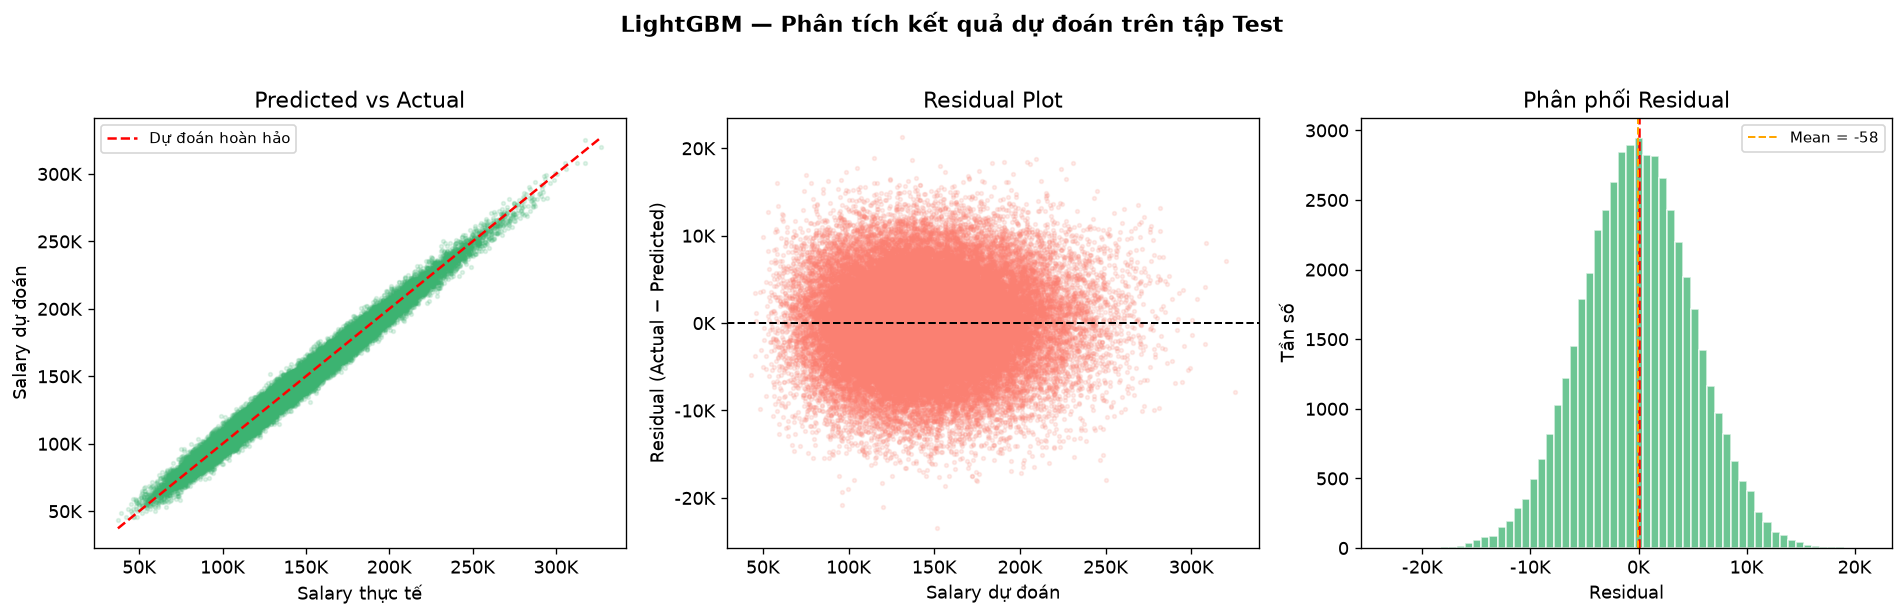

Đã lưu: figure/LGBM/03_prediction_analysis.png


In [9]:
residuals = y_test.values - y_pred_lgb

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Predicted vs Actual ───────────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_lgb, alpha=0.15, s=5, color='mediumseagreen')
lims = [min(y_test.min(), y_pred_lgb.min()), max(y_test.max(), y_pred_lgb.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Dự đoán hoàn hảo')
axes[0].set_xlabel('Salary thực tế')
axes[0].set_ylabel('Salary dự đoán')
axes[0].set_title('Predicted vs Actual')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# ── Residual vs Predicted ─────────────────────────────────────────────────────
axes[1].scatter(y_pred_lgb, residuals, alpha=0.15, s=5, color='salmon')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Salary dự đoán')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# ── Phân phối Residual ────────────────────────────────────────────────────────
axes[2].hist(residuals, bins=60, color='mediumseagreen', alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.2,
                label=f'Mean = {residuals.mean():,.0f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Tần số')
axes[2].set_title('Phân phối Residual')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[2].legend(fontsize=9)

plt.suptitle('LightGBM — Phân tích kết quả dự đoán trên tập Test',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_prediction_analysis.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/LGBM/03_prediction_analysis.png")


## 7. Feature Importance — Mức độ quan trọng của từng đặc trưng

LightGBM cung cấp hai cách đo feature importance:

| Phương pháp | Ý nghĩa |
|---|---|
| **`gain`** | Tổng mức độ giảm hàm mất mát khi feature được dùng để split — **phản ánh đóng góp thực sự** |
| **`split`** | Số lần feature được chọn làm điểm phân chia — dễ bias nếu feature có nhiều giá trị unique |

> Ta ưu tiên dùng `importance_type='gain'` vì phản ánh chính xác hơn đóng góp của feature.


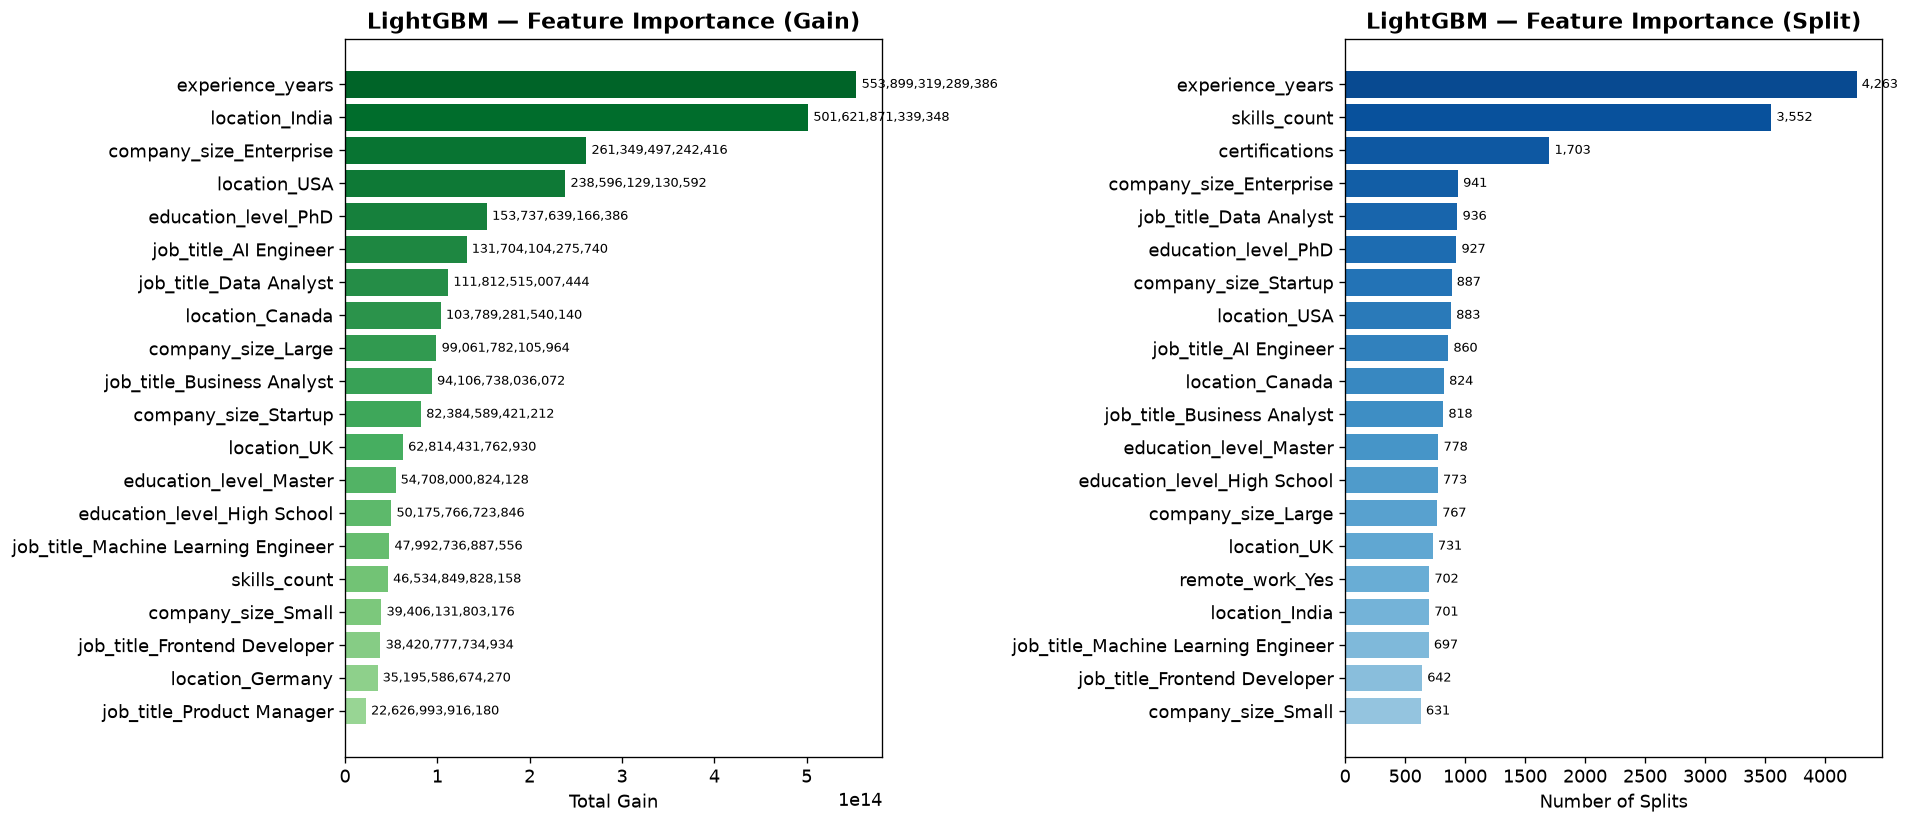

Đã lưu: figure/LGBM/04_feature_importance.png
 Gain rank             Feature (Gain)      Gain value         Feature (Split)  Split count
         1           experience_years 553899319289386        experience_years         4263
         2             location_India 501621871339348            skills_count         3552
         3    company_size_Enterprise 261349497242416          certifications         1703
         4               location_USA 238596129130592 company_size_Enterprise          941
         5        education_level_PhD 153737639166386  job_title_Data Analyst          936
         6      job_title_AI Engineer 131704104275740     education_level_PhD          927
         7     job_title_Data Analyst 111812515007444    company_size_Startup          887
         8            location_Canada 103789281540140            location_USA          883
         9         company_size_Large  99061782105964   job_title_AI Engineer          860
        10 job_title_Business Analyst  94106

In [10]:
fi_gain  = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=feature_names
)
fi_split = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='split'),
    index=feature_names
)

fi_top20_gain  = fi_gain.nlargest(20).sort_values()
fi_top20_split = fi_split.nlargest(20).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gain
colors_g = plt.cm.Greens(np.linspace(0.4, 0.9, len(fi_top20_gain)))
bars_g = axes[0].barh(fi_top20_gain.index, fi_top20_gain.values, color=colors_g)
axes[0].set_xlabel('Total Gain')
axes[0].set_title('LightGBM — Feature Importance (Gain)', fontweight='bold')
for bar, val in zip(bars_g, fi_top20_gain.values):
    axes[0].text(val + fi_top20_gain.max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=8)

# Split
colors_s = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_top20_split)))
bars_s = axes[1].barh(fi_top20_split.index, fi_top20_split.values, color=colors_s)
axes[1].set_xlabel('Number of Splits')
axes[1].set_title('LightGBM — Feature Importance (Split)', fontweight='bold')
for bar, val in zip(bars_s, fi_top20_split.values):
    axes[1].text(val + fi_top20_split.max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/04_feature_importance.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/LGBM/04_feature_importance.png")

# Bảng so sánh top 10
fi_compare = pd.DataFrame({
    'Gain rank'   : range(1, 11),
    'Feature (Gain)' : fi_gain.nlargest(10).index.tolist(),
    'Gain value'  : fi_gain.nlargest(10).values.round(0).astype(int),
    'Feature (Split)': fi_split.nlargest(10).index.tolist(),
    'Split count' : fi_split.nlargest(10).values.astype(int)
})
print(fi_compare.to_string(index=False))


## 8. Khoảng dự đoán — Quantile Regression

### Tại sao LightGBM dùng Quantile Regression thay vì phương pháp cây?

Với Random Forest, ta lấy phân phối của 200 cây để ước tính khoảng dự đoán.  
Với LightGBM (Boosting), các cây **không độc lập** nên không thể làm tương tự.

**Quantile Regression** là phương pháp phù hợp:
- Huấn luyện 3 mô hình riêng biệt với hàm mất mát **Pinball Loss** (hay còn gọi là Quantile Loss):

$$L_q(y, \hat{y}) = q \cdot \max(y - \hat{y}, 0) + (1-q) \cdot \max(\hat{y} - y, 0)$$

- `alpha=0.10` → dự đoán quantile 10% (mức thấp — P10)  
- `alpha=0.50` → dự đoán quantile 50% (median)  
- `alpha=0.90` → dự đoán quantile 90% (mức cao — P90)

Kết quả: 3 đường dự đoán bao phủ 80% khoảng biến động của lương.


In [11]:
# Các tham số dùng chung cho 3 quantile models (giống model chính)
SHARED_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# ── Quantile P10 ──────────────────────────────────────────────────────────────
print("Huấn luyện Quantile P10 (mức lương thấp)...")
lgb_p10 = lgb.LGBMRegressor(objective='quantile', alpha=0.10, **SHARED_PARAMS)
lgb_p10.fit(X_train, y_train, feature_name=feature_names)

# ── Quantile P50 (median) ─────────────────────────────────────────────────────
print("Huấn luyện Quantile P50 (median)...")
lgb_p50 = lgb.LGBMRegressor(objective='quantile', alpha=0.50, **SHARED_PARAMS)
lgb_p50.fit(X_train, y_train, feature_name=feature_names)

# ── Quantile P90 ──────────────────────────────────────────────────────────────
print("Huấn luyện Quantile P90 (mức lương đàm phán)...")
lgb_p90 = lgb.LGBMRegressor(objective='quantile', alpha=0.90, **SHARED_PARAMS)
lgb_p90.fit(X_train, y_train, feature_name=feature_names)

y_pred_p10 = lgb_p10.predict(X_test)
y_pred_p50 = lgb_p50.predict(X_test)
y_pred_p90 = lgb_p90.predict(X_test)

interval_width = y_pred_p90 - y_pred_p10

print()
print("=" * 55)
print("  Quantile Regression — Thống kê khoảng dự đoán")
print("=" * 55)
print(f"  P10 trung bình : {y_pred_p10.mean():>12,.0f} USD")
print(f"  P50 trung bình : {y_pred_p50.mean():>12,.0f} USD")
print(f"  P90 trung bình : {y_pred_p90.mean():>12,.0f} USD")
print(f"  Width trung bình (P90−P10): {interval_width.mean():>8,.0f} USD")
print("=" * 55)


Huấn luyện Quantile P10 (mức lương thấp)...
Huấn luyện Quantile P50 (median)...
Huấn luyện Quantile P90 (mức lương đàm phán)...

  Quantile Regression — Thống kê khoảng dự đoán
  P10 trung bình :      139,136 USD
  P50 trung bình :      145,778 USD
  P90 trung bình :      152,306 USD
  Width trung bình (P90−P10):   13,170 USD


### 8.1 Trực quan hóa khoảng dự đoán

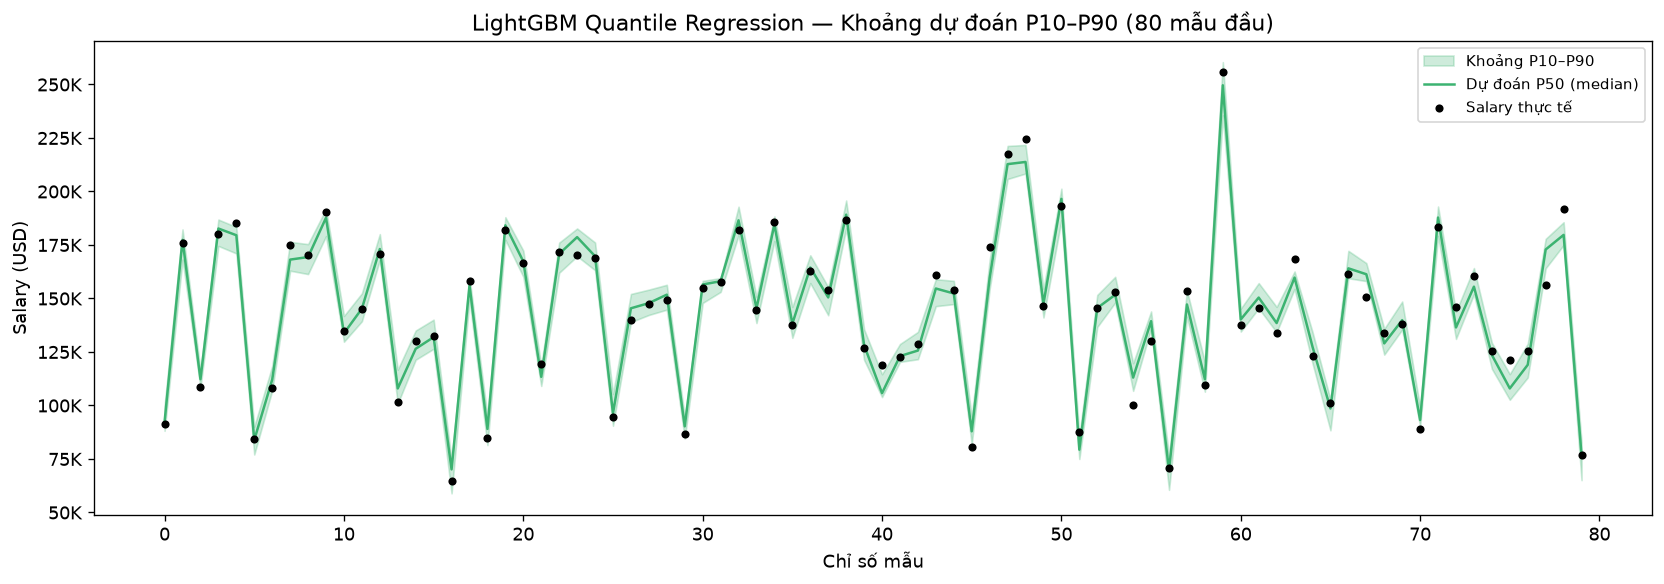

Đã lưu: figure/LGBM/05_prediction_interval.png


In [12]:
n_show = 80
idx    = np.arange(n_show)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(idx, y_pred_p10[:n_show], y_pred_p90[:n_show],
                alpha=0.25, color='mediumseagreen', label='Khoảng P10–P90')
ax.plot(idx, y_pred_p50[:n_show],  color='mediumseagreen', linewidth=1.5,
        label='Dự đoán P50 (median)')
ax.scatter(idx, y_test.values[:n_show], color='black', s=15, zorder=5,
           label='Salary thực tế')
ax.set_xlabel('Chỉ số mẫu')
ax.set_ylabel('Salary (USD)')
ax.set_title('LightGBM Quantile Regression — Khoảng dự đoán P10–P90 (80 mẫu đầu)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/05_prediction_interval.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/LGBM/05_prediction_interval.png")


### 8.2 Đánh giá chất lượng khoảng dự đoán

**Coverage rate** và **Pinball Loss** là hai metric đánh giá chất lượng Quantile Regression:

- **Coverage rate**: tỷ lệ mẫu có giá trị thực nằm trong [P10, P90] — kỳ vọng ≈ 80%  
- **Pinball Loss**: hàm mất mát của Quantile Regression — càng nhỏ càng tốt


Coverage rate (P10–P90): 78.61%
  Số mẫu trong khoảng : 39,303 / 50,000

Pinball Loss:
  P10 (alpha=0.10) : 937.36
  P50 (alpha=0.50) : 2,074.43
  P90 (alpha=0.90) : 922.13


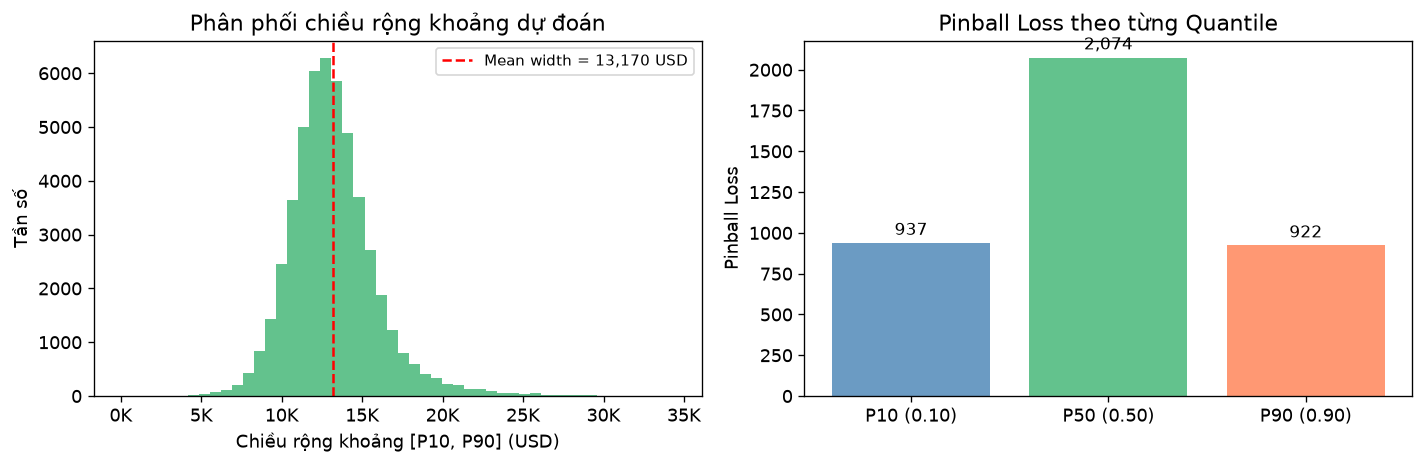

Đã lưu: figure/LGBM/06_quantile_evaluation.png


In [13]:
# Coverage
within   = ((y_test.values >= y_pred_p10) & (y_test.values <= y_pred_p90)).sum()
coverage = within / len(y_test) * 100
print(f"Coverage rate (P10–P90): {coverage:.2f}%")
print(f"  Số mẫu trong khoảng : {within:,} / {len(y_test):,}")

# Pinball Loss
def pinball_loss(y_true, y_pred, alpha):
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, alpha * err, (alpha - 1) * err))

pb10 = pinball_loss(y_test.values, y_pred_p10, 0.10)
pb50 = pinball_loss(y_test.values, y_pred_p50, 0.50)
pb90 = pinball_loss(y_test.values, y_pred_p90, 0.90)
print(f"\nPinball Loss:")
print(f"  P10 (alpha=0.10) : {pb10:,.2f}")
print(f"  P50 (alpha=0.50) : {pb50:,.2f}")
print(f"  P90 (alpha=0.90) : {pb90:,.2f}")

# Phân phối chiều rộng khoảng
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(interval_width, bins=50, color='mediumseagreen', alpha=0.8)
axes[0].axvline(interval_width.mean(), color='red', linestyle='--',
                label=f'Mean width = {interval_width.mean():,.0f} USD')
axes[0].set_xlabel('Chiều rộng khoảng [P10, P90] (USD)')
axes[0].set_ylabel('Tần số')
axes[0].set_title('Phân phối chiều rộng khoảng dự đoán')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# Pinball Loss bar chart
alphas = ['P10 (0.10)', 'P50 (0.50)', 'P90 (0.90)']
losses = [pb10, pb50, pb90]
axes[1].bar(alphas, losses, color=['steelblue', 'mediumseagreen', 'coral'], alpha=0.8)
for i, (alpha, loss) in enumerate(zip(alphas, losses)):
    axes[1].text(i, loss + 50, f'{loss:,.0f}', ha='center', fontsize=10)
axes[1].set_title('Pinball Loss theo từng Quantile')
axes[1].set_ylabel('Pinball Loss')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/06_quantile_evaluation.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/LGBM/06_quantile_evaluation.png")


## 9. Ví dụ dự đoán cho hồ sơ mới (demo hệ thống)

In [14]:
def predict_salary_lgb(profile: dict, preprocessor,
                       model_point, model_p10, model_p90):
    """
    Dự đoán mức lương với khoảng tin cậy bằng LightGBM Quantile Regression.

    Parameters
    ----------
    profile      : dict — thông tin ứng viên (raw)
    preprocessor : Pipeline đã fit từ Preprocessing notebook
    model_point  : LGBMRegressor — mô hình dự đoán điểm (MSE)
    model_p10    : LGBMRegressor — Quantile P10
    model_p90    : LGBMRegressor — Quantile P90

    Returns
    -------
    dict — {'point', 'low_p10', 'median_p50', 'high_p90'}
    """
    df_new = pd.DataFrame([profile])
    X_new  = preprocessor.transform(df_new)

    return {
        'point'     : model_point.predict(X_new)[0],
        'low_p10'   : model_p10.predict(X_new)[0],
        'high_p90'  : model_p90.predict(X_new)[0],
    }


# ── Hồ sơ mẫu ────────────────────────────────────────────────────────────────
sample_profile = {
    'job_title'       : 'Data Scientist',
    'experience_years': 5,
    'education_level' : 'Master',
    'skills_count'    : 8,
    'industry'        : 'Technology',
    'company_size'    : 'Large',
    'location'        : 'USA',
    'remote_work'     : 'Hybrid',
    'certifications'  : 3
}

result = predict_salary_lgb(
    sample_profile, preprocessor,
    lgb_model, lgb_p10, lgb_p90
)

print("=" * 55)
print("  Kết quả tư vấn lương (LightGBM)")
print("=" * 55)
print(f"  Hồ sơ    : {sample_profile['job_title']}, "
      f"{sample_profile['experience_years']} năm KN, {sample_profile['education_level']}")
print(f"  Địa điểm : {sample_profile['location']} | "
      f"Công ty  : {sample_profile['company_size']}")
print("-" * 55)
print(f"  Mức thấp hợp lý (P10) : $ {result['low_p10']:>10,.0f}")
print(f"  Mức dự đoán trung tâm : $ {result['point']:>10,.0f}")
print(f"  Mức đàm phán (P90)    : $ {result['high_p90']:>10,.0f}")
print("=" * 55)


  Kết quả tư vấn lương (LightGBM)
  Hồ sơ    : Data Scientist, 5 năm KN, Master
  Địa điểm : USA | Công ty  : Large
-------------------------------------------------------
  Mức thấp hợp lý (P10) : $    172,688
  Mức dự đoán trung tâm : $    181,906
  Mức đàm phán (P90)    : $    189,678


## 10. Lưu model và kết quả

In [15]:
# ── Lưu các model ────────────────────────────────────────────────────────────
joblib.dump(lgb_model, 'model_lgbm.joblib')
joblib.dump(lgb_p10,   'model_lgbm_p10.joblib')
joblib.dump(lgb_p50,   'model_lgbm_p50.joblib')
joblib.dump(lgb_p90,   'model_lgbm_p90.joblib')
print("Đã lưu: model_lgbm.joblib, model_lgbm_p10/p50/p90.joblib")

# ── Lưu kết quả dự đoán ──────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'y_actual'    : y_test.values,
    'y_pred'      : y_pred_lgb,
    'y_pred_p10'  : y_pred_p10,
    'y_pred_p50'  : y_pred_p50,
    'y_pred_p90'  : y_pred_p90,
    'residual'    : y_test.values - y_pred_lgb
})
results_df.to_csv('lgbm_predictions.csv', index=False)
print("Đã lưu: lgbm_predictions.csv")

# ── Lưu metrics ──────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'model'    : 'LightGBM',
    'RMSE'     : round(rmse, 2),
    'MAE'      : round(mae,  2),
    'R2'       : round(r2,   4),
    'MAPE'     : round(mape, 2),
    'Coverage' : round(coverage, 2)
}])
metrics_df.to_csv('lgbm_metrics.csv', index=False)
print("Đã lưu: lgbm_metrics.csv")

print()
print("=" * 55)
print("  Tóm tắt kết quả LightGBM Regressor")
print("=" * 55)
print(f"  RMSE     : {rmse:>12,.2f} USD")
print(f"  MAE      : {mae:>12,.2f} USD")
print(f"  R²       : {r2:>12.4f}")
print(f"  MAPE     : {mape:>11.2f} %")
print(f"  Coverage P10–P90 : {coverage:.2f}%")
print("=" * 55)


Đã lưu: model_lgbm.joblib, model_lgbm_p10/p50/p90.joblib
Đã lưu: lgbm_predictions.csv
Đã lưu: lgbm_metrics.csv

  Tóm tắt kết quả LightGBM Regressor
  RMSE     :     5,115.24 USD
  MAE      :     4,077.26 USD
  R²       :       0.9813
  MAPE     :        3.01 %
  Coverage P10–P90 : 78.61%
